## 04. 텍스트 분류 실습 - 20 뉴스그룹 분류
사이킷런이 내부에 가지고 있는 예제 데이터인 20 뉴스그룹 데이터 세트를 이용해 텍스트 분류를 적용해 보겠습니다. 텍스트 분류는 특정 문서의 분류를 학습 데이터를 통해 학습해 모델을 생성한 뒤 이 학습 모델을 이용해 다른 문서의 분류를 예측하는 것입니다.

사이킷런은 fetch_20newsgroups() API를 이용해 뉴스그룹의 분류를 수행해 볼 수 있는 예제 데이터를 제공합니다. 텍스트를 피처 벡터화로 변환하면 일반적으로 희소 행렬 형태가 됩니다. 그리고 이러한 희소 행렬에 분류를 효과적으로 잘 처리할 수 있는 알고리즘은 로지스틱 회귀, 선형 서포트 벡터 머신, 나이브 베이즈 등입니다. 이 중 로지스틱 회귀를 이용해 분류를 수행해 보겠습니다. 텍스트를 기반으로 분류를 수행할 때는 먼저 텍스트를 정규화한 뒤 피처 벡터화를 적용합니다. 그리고 그 이후에 적합한 머신러닝 알고리즘을 적용해 분류를 학습/예측/평가합니다. 이번 절에서는 카운트 기반과 TF-IDF 기반의 벡터화를 차례로 적용해 예측 성능을 비교하고, 피처 벡터화를 위한 파라미터와 GridSearchCV 기반의 하이퍼 파라미터 튜닝. 그리고 사이킷런의 Pipeline 객체를 통해 피처 벡터화 파라미터와 GridSearchCV 기반의 하이퍼 파라미터 튜닝을 한꺼번에 수행하는 방법을 소개하겠습니다.

## 텍스트 정규화

fetch_20newsgroups()는 인터뎃에서 로컬 컴퓨터로 데이터를 먼저 내려받은 후에 메모리로 데이터를 로딩합니다. 수행하려는 컴퓨터에 인터넷 연결이 정상적으로 되는지 확인한 후에 다음 예제를 수행합니다.

In [6]:
from sklearn.datasets import fetch_20newsgroups

news_data = fetch_20newsgroups(subset='all', random_state=156)

fetch_20newsgroups( )는 사이킷런의 다른 데이터 세트 예제와 같이 파이썬 딕셔너리와 유사한 Bunch 객체를 반환합니다. 어떠한 key 값을 가지고 있는지 확인해 보겠습니다.

In [7]:
print(news_data.keys())

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])


fetch_20newsgroups() API 역시 load_xxx() API와 유사한 Key 값을 가지고 있습니다. filenames라는 key 이름이 눈에 띄는데, 이는 fetch_20newsgroups() API가 인터넷에서 내려받아 로컬 컴퓨터에 저장하는 디렉터리와 파일명을 지칭합니다. 다음으로 Target 클래스가 어떻게 구성돼 있는지 확인해 보겠습니다.

In [8]:
import pandas as pd

print('target 클래스의 값과 분포도 \n', pd.Series(news_data.target).value_counts().sort_index())
print('target 클래스의 이름들 \n', news_data.target_names)

target 클래스의 값과 분포도 
 0     799
1     973
2     985
3     982
4     963
5     988
6     975
7     990
8     996
9     994
10    999
11    991
12    984
13    990
14    987
15    997
16    910
17    940
18    775
19    628
Name: count, dtype: int64
target 클래스의 이름들 
 ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


Target 클래스의 값은 0부터 19까지 20개로 구성돼 있으며, 위의 출력 결과처럼 주어졌습니다(Target 값 0: alt.atheism, Target 값 1: comp.graphics, ...). 개별 데이터가 텍스트로 어떻게 구성돼 있는지 데이터를 한 개만 추출해 값을 확인해 보겠습니다.

In [9]:
print(news_data.data[0])

From: egreen@east.sun.com (Ed Green - Pixel Cruncher)
Subject: Re: Observation re: helmets
Organization: Sun Microsystems, RTP, NC
Lines: 21
Distribution: world
Reply-To: egreen@east.sun.com
NNTP-Posting-Host: laser.east.sun.com

In article 211353@mavenry.altcit.eskimo.com, maven@mavenry.altcit.eskimo.com (Norman Hamer) writes:
> 
> The question for the day is re: passenger helmets, if you don't know for 
>certain who's gonna ride with you (like say you meet them at a .... church 
>meeting, yeah, that's the ticket)... What are some guidelines? Should I just 
>pick up another shoei in my size to have a backup helmet (XL), or should I 
>maybe get an inexpensive one of a smaller size to accomodate my likely 
>passenger? 

If your primary concern is protecting the passenger in the event of a
crash, have him or her fitted for a helmet that is their size.  If your
primary concern is complying with stupid helmet laws, carry a real big
spare (you can put a big or small head in a big helmet, bu

텍스트 데이터를 확인해 보면 뉴스그룹 기사의 내용뿐만 아니라 뉴스그룹 제목, 작성자, 소속, 이메일 등의 다양한 정보를 가지고 있습니다. 이 중에서 내용을 제외하고 제목 등의 다른 정보는 제거합니다. 왜냐하면 제목과 소속, 이메일 주소 등의 헤더와 푸터 정보들은 뉴스그룹 분류의 Target 클래스 값과 유사한 데이터를 가지고 있는 경우가 많기 때문입니다. 이 피처들을 포함하게 되면 왠만한 ML 알고리즘을 적용해도 상당히 높은 예측 성능을 나타냅니다. 따라서 이들 헤더와 푸터 정보를 포함하는 것은 이 장에서 수행하려는 텍스트 분석의 의도를 벗어나기에 순수한 텍스트만으로 구성된 기사 내용으로 어떤 뉴스그룹에 속하는지 분류할 것입니다. remove 파라미터를 이용하면 뉴스그룹 기사의 헤더(header), 푸터(footer) 등을 제거할 수 있습니다. 또한 fetch_20newsgroups()는 subset 파라미터를 이용해 학습 데이터 세트와 테스트 데이터 세트를 분리해 내려받을 수 있습니다.

In [10]:
from sklearn.datasets import fetch_20newsgroups

# subset='train'으로 학습용 데이터만 추출, remove=('headers', 'footers', ’quotes')로 내용만 추출
train_news = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'),
                                random_state=156)
X_train = train_news.data
y_train = train_news.target

# subset='test'으로 테스트 데이터만 추출, remove=('headers', 'footers', ’quotes')로 내용만 추출
test_news= fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'),
                              random_state=156)
X_test = test_news.data
y_test = test_news.target
print('학습 데이터 크기 {0}, 테스트 데이터 크기 {1}'.format(len(train_news.data),
len(test_news.data)))

학습 데이터 크기 11314, 테스트 데이터 크기 7532


## 피처 벡터화 변환과 머신러닝 모델 학습/예측/평가
학습 데이터는 11314개의 뉴스그룹 문서가 리스트 형태로 주어지고, 테스트 데이터는 7532개의 문서가 역시 리스트 형태로 주어졌습니다. CountVectorizer를 이용해 학습 데이터의 텍스트를 피처 벡터화하겠습니다. 테스트 데이터 역시 피처 벡터화를 수행하는데, 한 가지 반드시 유의해야 할 점이 있습니다. 바로 테스트 데이터에서 CountVectorizer를 적용할 때는 반드시 학습 데이터를 이용해 fit()이 수행된 CountVectorizer 객체를 이용해 테스트 데이터를 변환(transform)해야 한다는 것입니다. 그래야만 학습 시 설정된 CountVectorizer의 피처 개수와 테스트 데이터를 CountVectorizer로. 변환할 피처 개수가 같아집니다. 테스트 데이터의 피처 벡터화는 학습 데이터에 사용된 CountVectorizer 객체 변수인 cnt_vect.transform()을 이용해 변환합니다.

테스트 데이터의 피처 벡터화 시 fit_transform()을 사용하면 안 된다는 점도 유의하세요. CountVectorizer.fit_transform(테스트 데이터)을 테스트 데이터 세트에 적용하면 테스트 데이터 기반으로 다시 CountVectorizer가 fit()을 수행하고 transform( )하기 때문에 학습 시 사용된 피처 개수와 예측 시 사용할 피처 개수가 달라집니다.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Count Vectorization으로 피처 벡터화 변환 수행.
cnt_vect = CountVectorizer()
cnt_vect.fit(X_train)
X_train_cnt_vect = cnt_vect .transform(X_train)

# 학습 데이터로 fit( )된 CountVectorizer를 이용해 테스트 데이터를 피터 벡터화 변환 수행.
X_test_cnt_vect = cnt_vect.transform(X_test)
print('학습 데이터 텍스트의 CountVectorizer Shape:', X_train_cnt_vect.shape)

학습 데이터 텍스트의 CountVectorizer Shape: (11314, 101631)


학습 데이터를 CountVectorizer로 피처를 추출한 결과 11314개의 문서에서 피처, 즉 단어가 101631개로 만들어졌습니다. 이렇게 피처 벡터화된 데이터에 로지스틱 회귀를 적용해 뉴스그룹에 대한 분류를 예측해 보겠습니다.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# LogisticRegression을 이용하여 학습/예측/평가 수행.
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_cnt_vect , y_train)
pred = lr_clf.predict(X_test_cnt_vect)
print('CountVectorized Logistic Regression의 예측 정확도는 {0：.3f}', format(accuracy_score(y_test,pred)))

CountVectorized Logistic Regression의 예측 정확도는 {0：.3f} 0.6168348380244291


Count 기반으로 피처 벡터화가 적용된 데이터 세트에 대한 로지스틱 회귀의 예측 정확도는 약 0.616입니다. 이번에는 Count 기반에서 TF-IDF 기반으로 벡터화를 변경해 예측 모델을 수행하겠습니다.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터화를 적용해 학습 데이터 세트와 테스트 데이터 세트 변환.
tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)

# LogisticRegression을 이용해 학습/예측/평가 수행.
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)
print('TF-IDF Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Logistic Regression의 예측 정확도는 0.678


TF-IDF가 단순 카운트 기반보다 훨씬 높은 예측 정확도를 제공합니다. 일반적으로 문서 내에 텍스트가 많고 많은 문서를 가지는 텍스트 분석에서 카운트 벡터화보다는 TF-IDF 벡터화가 좋은 예측 결과를 도출합니다.

텍스트 분석에서 머신러닝 모델의 성능을 향상시키는 중요한 2가지 방법은 최적의 ML 알고리즘을 선택하는 것과 최상의 피처 전처리를 수행하는 것입니다. 텍스트 정규화나 Count/TF-IDF 기반 피처 벡터화를 어떻게 효과적으로 적용했는지가 텍스트 기반의 머신러닝 성능에 큰 영향을 미칠 수 있습니다. 앞의 TF-IDF 벡터화는 기본 파라미터만 적용했지만, 이번에는 좀 더 다양한 파라미터를 적용해 보겠습니다. TfidfVectorizer 클래스의 스톱 워드를 기존 'None'에서 'english'로 변경하고, ngram_range는 기존 (1,1)에서 (1,2)로, max_df=300으로 변경한 뒤 다시 예측 성능을 측정해 보겠습니다.

In [14]:
# stop words 필터링을 추가하고 ngram을 기본 (1, 1)에서 (1, 2)로 변경해 피처 벡터화 적용.
tfidf_vect = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_df=300 )
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)
print('TF-IDF Vectorized Logistic Regression 의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Vectorized Logistic Regression 의 예측 정확도는 0.690


이번에는 GridSearchCV를 이용해 로지스틱 회귀의 하이퍼 파라미터 최적화를 수행해 보겠습니다. 로지스틱 회귀의 C 파라미터만 변경하면서 최적의 C값을 찾은 뒤 이 C값으로 학습된 모델에서 테스트 데이터로 예측해 성능을 평가하겠습니다.

In [15]:
from sklearn.model_selection import GridSearchCV

# 최적 C 값 도출 튜닝 수행. CV는 3 폴드 세트로 설정.
params = { 'C':[0.01, 0.1, 1, 5, 1]}
grid_cv_lr = GridSearchCV(lr_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv_lr.fit(X_train_tfidf_vect, y_train)
print('Logistic Regression best C parameter :', grid_cv_lr.best_params_ )

# 최적 C 값으로 학습된 grid_cv로 예측 및 정확도 평가.
pred = grid_cv_lr.predict(X_test_tfidf_vect)
print('TF-IDF Vectorized Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Logistic Regression best C parameter : {'C': 5}
TF-IDF Vectorized Logistic Regression의 예측 정확도는 0.701


로지스틱 회귀의 C가 10일 때 GridSearchCV의 교차 검증 테스트 세트에서 가장 좋은 예측 성능을 나타냈으며, 이를 테스트 데이터 세트에 적용해 약 0.704로 이전보다 약간 향상된 성능 수치가 됐습니다.

## 사이킷런 파이프라인(Pipeline) 사용 및 GridSearchCV와의 결합
사이킷런의 Pipeline 클래스를 이용하면 피처 벡터화와 ML 알고리즘 학습/예측을 위한 코드 작성을 한 번에 진행할 수 있습니다. 일반적으로 머신러닝에서 Pipeline이란 데이터의 가공, 변환 등의 전처리와 알고리즘 적용을 마치 '수도관(Pipe)에서 물이 흐르듯' 한꺼번에 스트림 기반으로 처리한다는 의미입니다. 이렇게 Pipeline을 이용하면 데이터의 전처리와 머신러닝 학습 과정을 통일된 API 기반에서 처리할 수 있어 더 직관적인 ML 모델 코드를 생성할 수 있습니다. 또한 대용량 데이터의 피처 벡터화 결과를 별도 데이터로 저장하지 않고 스트림 기반에서 바로 머신러닝 알고리즘의 데이터로 입력할 수 있기 때문에 수행 시간을 절약할 수 있습니다. 일반적으로 사이킷런 파이프라인은 텍스트 기반의 피처 벡터화뿐만 아니라 모든 데이터 전처리 작업과 Estimator를 결합할 수 있습니다. 예를 들어 스케일링 또는 벡터 정규화, PCA 등의 변환작업과분류, 회귀 등의 Estimator를 한 번에 결합하는 것입니다.

다음은 위에서 텍스트 분류 예제 코드를 Pipeline을 이용해 다시 작성한 코드입니다. Pipeline 객체는 다음과 같이 선언합니다.

In [16]:
import os
from sklearn.pipeline import Pipeline

pipeline = Pipeline([('tfidf_vect', TfidfVectorizer(stop_words='english')),
 ('lr_clf', LogisticRegression(random_state=156))])

In [17]:
from sklearn.pipeline import Pipeline

# TfidfVectorizer 객체를 tfidf_vect로, LogisticRegression 객체를 lr_clf로 생성하는 Pipeline 생성
pipeline = Pipeline([
('tfidf_vect', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_df=300)),
('lr_clf', LogisticRegression(solver='liblinear', C=10))
])

# 별도의 TfidfVectorizer 객체의 fit( ), transform( )과 LogisticRegression의 fit(), predict( )가
# 필요 없음.
# pipeline의 fit( )과 predict( )만으로 한꺼번에 피처 벡터화와 ML 학습/예측이 가능.
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
print ('Pipeline 을 통한 Logistic Regression 의 예측 정확도는 {0:.3f}'. format(accuracy_score(y_test, pred)))

Pipeline 을 통한 Logistic Regression 의 예측 정확도는 0.704


사이킷런은 GridSearchCV 클래스의 생성 파라미터로 Pipeline을 입력해 Pipeline 기반에서도 하이퍼 파라미터 튜닝을 GridSearchCV 방식으로 진행할 수 있게 지원합니다. 이렇게 하면 피처 벡터화를 위한 파라미터와 ML 알고리즘의 하이퍼 파라미터를 모두 한 번에 GridSearchCV를 이용해 최적화할 수 있습니다.

다음 예제는 GridSearchCV에 Pipeline을 입력하면서 TfidfVectorizer의 파라미터와 Logistic Regression의 하이퍼 파라미터를 함께 최적화합니다. 예제 코드를 잠깐 살펴보면 GridSearchCV에 Estimator가 아닌 Pipeline을 입력할 경우에는 param_grid의 입력값 설정이 기존과 약간 다릅니다. 딕셔너리 형태의 Key와 Value 값을 가지며, Value를 리스트 형태로 입력하는 것은 동일합니다. 다만 Key 값을 살펴보면 'tfidf_vect__ngram_range'와 같이 하이퍼 파라미터명이 객체 변수명과 결합돼 제공됩니다. Pipeline을 GridSearchCV에 인자로 입력하면 GridSearchCV는 Pipeline을 구성하는 피처 벡터화 객체의 파라미터와 Estimator 객체의 하이퍼 파라미터를 각각 구별할 수 있어야 하는데, 이때 개별 객체 명과 파라미터명/하이퍼 파라미터명을 결합해 Key 값으로 할당하는 것입니다. 가령 TfdifVectorizer 객체 변수인 tfdifLyect의 ngram_range 파라미터 값을 변화시키면서 최적화하기를 원한다면 객체 변수명인 tfidf_vect에 언더바2개를 연달아붙인 뒤 파라미터명인 ngram_range를 결합해 'tfidf_vect__ngram_range'를 Key 값으로 할당하는 것입니다.

Pipeline + GridSearchCV를 적용할 때 유의할 점은 모두의 파라미터를 최적화하려면 너무 많은 튜닝 시간이 소모된다는 점입니다. 피처 벡터화에 사용되는 파라미터와 GridSearchCV 하이퍼 파라미터를 합치면 최적화를 위한 너무 많은 경우의 수가 발생하기 쉽습니다. 다음 예제의 경우 Pipeline + GridSearchCV 기반으로 하이퍼 파라미터 튜닝을 적용해 27개의 파라미터 경우의 수 X 3개의 CV 로 총 81번의 학습과 검증을 수행했기에 저자의 랩톱 PC에서 약 24분이 소모됩니다.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english')),
    ('lr_clf', LogisticRegression())
])

# Pipeline에 기술된 각각의 객체 변수에 언더바(_) 2개를 연달아 붙여 GridSearchCV에 사용될
# 파라미터/하이퍼 파라미터 이름과 값을 설정.
params = {'tfidf_vect__ngram_range': [(1, 1), (1, 2), (1, 3)],
          'tfidf_vect__max_df': [100, 300, 700],
          'lr_clf__C': [1, 5, 10]
}

# GridSearchCV의 생성자에 Estimator가 아닌 Pipeline 객체 입력
grid_cv_pipe = GridSearchCV(pipeline, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv_pipe.fit(X_train, y_train)
print(grid_cv_pipe.best_params_, grid_cv_pipe.best_score_)

pred = grid_cv_pipe.predict(X_test)
print ('Pipeline을 통한 Logistic Regression 의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

Fitting 3 folds for each of 27 candidates, totalling 81 fits


TfidfVectorizer 객체의 max_df 파라미터가 700, ngramjrange 파라미터가 (1,2)로 피처 벡터화된 데이터 세트에 LogisticRegression의 C 하이퍼 파라미터에 10을 적용해 예측 분류를 수행할 때 가장 좋은 검증 세트 성능 수치가 도출됐습니다. 아쉽게도 이렇게 최적화한 파라미터를 기반으로 테스트 데이터 세트에 대해 예측했을 때의 정확도는 약 0.702로 크게 개선은 되지 않았습니다.

로지스틱 회귀 외에 서포트 벡터머신(Support Vector Machine)과 나이브 베이즈(Naive Bayes) 알고리즘도 희소 행렬 기반의 텍스트 분류에 자주 사용되는 머신러닝 알고리즘입니다. 이들을 이용한 모델도 만들어 볼 것을 권장합니다.

## 05. 감성 분석
## 감성 분석 소개
감성 분석(Sentiment Analysis)은 문서의 주관적인 감성/의견/감정/기분 등을 파악하기 위한 방법으로 소셜 미디어, 여론조사, 온라인 리뷰, 피드백 등 다양한 분야에서 활용되고 있습니다. 감성 분석은 문서 내 텍스트가 나타내는 여러 가지 주관적인 단어와문맥을 기반으로 감성(Sentiment) 수치를 계산하는 방법을 이용합니다. 이러한 감성 지수는 긍정 감성 지수와 부정 감성 지수로 구성되며 이들 지수를 합산해 긍정 감성 또는 부정 감성을 결정합니다.

이러한 감성 분석은 머신러닝 관점에서 지도학습과 비지도학습 방식으로 나눌 수 있습니다.

* 지도학습은 학습 데이터와 타깃 레이블 값을 기반으로 감성 분석 학습을 수행한 뒤 이를 기반으로 다른 데이터의 감성 분석을 예측하는 방법으로 일반적인 텍스트 기반의 분류와 거의 동일합니다.
* 비지도학습은 'Lexicon'이라는 일종의 감성 어휘 사전을 이용합니다. Lexicon은 감성 분석을 위한 용어와 문맥에 대한 다양한 정보를 가지고 있으며. 이를 이용해 문서의 긍정적, 부정적 감성 여부를 판단합니다.

## 지도학습 기반 감성 분석 실습 - IMDB 영화평
먼저 지도학습 기반으로 감성 분석을 수행하겠습니다. 유명한 IMDB의 영화 사이트의 영화평을 이용 하겠습니다(감성 분석이라는 타이틀이 붙었지만 지도학습 기반 감성 분석은 텍스트 기반의 이진 분류 라고 표현하고 싶습니다). 영화평의 텍스트를 분석해 감성 분석 결과가 긍정 또는 부정인지를 예측하는 모델을 만들어 보겠습니다.

labeledTrainData.tsv를 감성 분석을 위한 데이터 파일로 사용하겠습니다.

새로운 주피터 노트북을 생성하고 내려받은 labeledTrainData.tsv를 주피터 노트북이 있는 디렉터리로 이동합니다. labeledTrainData.tsv 파일은 탭(\t) 문자로 분리된 파일입니다. 판다스의 read_csv()를 이용하면 탭으로 칼럼이 분리된 파일도 DataFrame으로 쉽게 로딩할 수 있습니다. read_csv()의 인자로 sep="\t"를 명시해주면 됩니다.

In [ ]:
import pandas as pd

review_df = pd.read_csv('labeledTrainData.tsv', header=0, sep="\t", quoting=3)
review_df.head(3)

로드된 데이터를 살펴보겠습니다. 피처는 다음과 같습니다.

* id: 각 데이터의 id
* sentiment: 영화평(review)의 Sentiment 결과 값(Target Label). 1은 긍정적 평가, 0은 부정적 평가를 의미합니다.
* review: 영화평의 텍스트입니다.

이번에는 텍스트가 어떻게 구성되어 있는지 review 칼럼의 텍스트 값을 하나만 살펴보겠습니다.

In [19]:
print(review_df['review'][0])

NameError: name 'review_df' is not defined

HTML 형식에서 추출해 br \ 태그가 여전히 존재합니다. br \ 문자열은 피처로 만들 필요가 없으니 삭제하겠습니다. 판다스의 DataFrame/Series는 문자열 연산을 지원하기 위해 str 속성을 이용합니다. DataFrame/Series 객체에서 str을 적용하면 다양한 문자열 연산을 수행할 수 있습니다. replace()를 str에 적용해 br\
태그를 공백으로 모두 바꾸겠습니다.

그리고 영어가 아닌 숫자/특수문자 역시 Sentiment를 위한 피처로는 별 의미가 없어 보이므로 이들도 모두 공란으로 변경하겠습니다. 숫자/특수문자를 찾고 이를 변환하는 것은 정규 표현식을 이용하겠습니다(정규 표현식을 아는 것은 텍스트 처리를 하는 데 매우 큰 도움이 됩니다. 간단한 정규 표현식은 인터넷 등을 통해 익혀 두는 것이 유용합니다). 파이썬의 re 모듈은 편리하게 정규 표현식을 지원합니다. 정규 표현식 [^a-zA-Z]의 의미는 영어 대/소문자가 아닌 모든 문자를 찾는 것입니다. re.sub("[^a-zA-Z]", " ", x)는 영어 대/소문자가 아닌 모든 문자를 찾아서 공란으로 변경합니다. 판다스 DataFrame에 re.sub()는 lambda 식을 이용해 적용하겠습니다.

In [20]:
import re

#  html 태그는 replace 함수로 공백으로 변환
review_df['review'] = review_df['review'].str.replace('', ' ')

# 파이썬의 정규 표현식 모듈인 re를 이용해 영어 문자열이 아닌 문자는 모두 공백으로 변환
review_df['review'] = review_df['review'].apply(lambda x : re.sub("[^a-zA-Z]", " ", x))

NameError: name 'review_df' is not defined

결정 값 클래스인 sentiment 칼럼을 별도로 추출해 결정 값 데이터 세트를 만들고, 원본 데이터 세트에서 id와 sentiment 칼럼을 삭제해 피처 데이터 세트를 생성합니다. 그리고 train_test_split()을 이용해 학습용과 테스트용 데이터 세트로 분리하겠습니다.

In [21]:
from sklearn.model_selection import train_test_split

class_df = review_df['sentiment']
feature_df = review_df.drop(['id', 'sentiment'], axis=1, inplace=False)

X_train, X_test, y_train, y_test= train_test_split(feature_df, class_df, test_size=0.3,
                                                   random_state=156)
X_train.shape, X_test.shape

NameError: name 'review_df' is not defined

학습용 데이터는 17500개의 리뷰, 테스트용 데이터는 7500개의 리뷰로 구성되었습니다.

이제 감상평(Review) 텍스트를 피처 벡터화한 후에 ML 분류 알고리즘을 적용해 예측 성능을 측정하겠습니다. 앞 절에서 설명한 Pipeline 객체를 이용해 이 두 가지를 한꺼번에 수행하겠습니다. 먼저 Count 벡터화를 적용해 예측 성능을 측정하고, 다음으로 TF-IDF 벡터화를 적용해 보겠습니다. Classifier는 LogisticRegression을 이용합니다. 예측 성능 평가는 이진 분류임을 고려해 테스트 데이터 세트의 정확도와 ROC-AUC를 모두 측정하겠습니다.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# 스톱 워드는 English, ngram은 (1, 2)로 설정해 CountVectorization 수행.
# LogisticRegression의 C는 10으로 설정.
pipeline = Pipeline([
    ('cnt_vect', CountVectorizer(stop_words='english', ngram_range=(1, 2) )),
    ('lr_clf', LogisticRegression(solver='liblinear', C=10))])

# Pipeline 객체를 이용해 fit(), predictO로 학습/예측 수행. predict_j)roba()는 roc_auc 때문에 수행.
pipeline.fit(X_train['review'], y_train)
pred = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:, 1]
print('예측 정확도는 {0:.4f}, ROC-AUC는 {1:.4f}'.format(accuracy_score(y_test, pred),
                                                 roc_auc_score(y_test, pred_probs)))

TypeError: list indices must be integers or slices, not str

이번에는 TF-IDF 벡터화를 적용해 다시 예측 성능을 측정해 보겠습니다. 예제 코드는 위와 거의 같고, 단지 Pipeline에서 CountVectorizer를 TfidfVectorizer로 변경하면 됩니다.

In [23]:
# 스톱 워드는 english, filtering, ngram은 (1, 2)로 설정해 TF-IDF 벡터화 수행.
# LogisticRegression의 C는 10으로 설정.
pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english', ngram_range=(1, 2) )),
     ('lr_clf', LogisticRegression(solver='liblinear', C=10))])

pipeline.fit(X_train['review'], y_train)
pred = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:, 1 ]

print('예측 정확도는 {0:.4f}, ROC-AUC는 {1:.4f}'.format(accuracy_score(y_test, pred),
                                                 roc_auc_score(y_test, pred_probs)))

TypeError: list indices must be integers or slices, not str

TF-IDF 기반 피처 벡터화의 예측 성능이 조금 더 나아졌습니다.

## 비지도학습 기반 감성 분석 소개
비지도 감성 분석은 Lexicon을 기반으로 하는 것입니다. 위의 지도 감성 분석은 데이터 세트가 레이블 값을 가지고 있었습니다. 하지만 많은 감성 분석용 데이터는 이러한 결정된 레이블 값을 가지고 있지 않습니다. 이러한 경우에 Lexicon은 유용하게 사용될 수 있습니다(한글을 지원하는 Lexicon이 없어서 매우 아쉽습니다).

Lexicon은 일반적으로 어휘집을 의미하지만 여기서는 주로 감성만을 분석하기 위해 지원하는 감성 어휘 사전입니다. 줄여서 감성 사전으로 표현하겠습니다. 감성 사전은 긍정(Positive) 감성 또는 부정(Negative) 감성의 정도를 의미하는 수치를 가지고 있으며 이를 감성 지수(Polarity score)라고 합니다. 이 감성 지수는 단어의 위치나 주변 단어, 문맥, POS(Part of Speech) 등을 참고해 결정됩니다. 이러한 감성 사전을 구현한 대표격은 NLTK 패키지입니다. NLTK는 많은 서브 모듈을 가지고 있으며 그중에 감성 사전인 Lexicon 모듈도 포함돼 있습니다.

여기서 감성 사전을 좀 더 상세히 이해하기 위해 NLTK 패키지의 WordNet을 먼저 설명하겠습니다. NLTK에서 제공하는 WordNet 모듈은 방대한 영어 어휘 사전입니다. WordNet은 단순한 어휘 사전이 아닌 시맨틱 분석을 제공하는 어휘 사전입니다.

텍스트 분석(Text Analytics)을 공부하다 보면 아마도 '시맨틱(semantic)'이라는 용어를 자주 접하게 될 것입니다. 시맨틱은 간단히 표현하면 '문맥상 의미'입니다. 알다시피 '말'이라는 것은 상황에 따라, 문맥에 따라, 화자의 몸짓이나 어조에 따라 다르게 해석될 수 있습니다. 동일한 단어나 문장이라도 다른 환경과 문맥에서는 다르게 표현되거나 이해될 수 있습니다.

영어단어 'Present'는 '선물'이라는 의미도 있지만, '현재'라는 의미도 있습니다. 우리말의 '밥 먹었어?'라는 표현은 단순히 식사했는가를 묻는 표현일 수도 있지만 안부를 묻는 표현일 수도 있습니다. 언어학에서 이러한 시맨틱을 표현하기 위해서 여러 가지 규칙을 정해왔으며, NLP 패키지는 시맨틱을 프로그램적으로 인터페이스할 수 있는 다양한 방법을 제공합니다.

이처럼 WordNet은 다양한 상황에서 같은 어휘라도 다르게 사용되는 어휘의 시맨틱 정보를 제공하며, 이를 위해 각각의 품사(명사, 동사, 형용사, 부사 등)로 구성된 개별 단어를 Synset(Sets of cognitive synonyms)이라는 개념을 이용해 표현합니다. Synset은 단순한 하나의 단어가 아니라 그 단어가 가지는 문맥, 시맨틱 정보를 제공하는 WordNet의 핵심 개념입니다.

NLTK의 감성 사전이 감성에 대한 훌륭한 사전 역할을 제공한 장점은 인정해야 하겠지만, 아쉽게도 예측 성능은 그리 좋지 못하다는 단점이 있습니다. 그 때문에 실제 업무의 적용은 NLTK 패키지가 아닌 다른 감성 사전을 적용하는 것이 일반적입니다. NLTK를 포함한 대표적인 감성 사전은 다음과 같습니다.

* SentiWordNet: NLTK 패키지의 WordNet과 유사하게 감성 단어 전용의 WordNet을 구현한 것입니다. WordNet의 Synset 개념을 감성 분석에 적용한 것입니다. WordNet의 Synset별로 3가지 감성 점수(sentiment score)를 할당합니다. 긍정 감성 지수, 부정 감성 지수, 객관성 지수가 그것입니다. 긍정 감성 지수는 해당 단어가 감성적으로 얼마나 긍정적인가를, 부정 지수는 얼마나 감성적으로 부정적인가를 수치로 나타낸 것입니다. 객관성 지수는 긍정/부정 감성 지수와 완전히 반대되는 개념으로 단어가 감성과 관계없이 얼마나 객관적인지를 수치로 나타낸 것입니다. 문장별로 단어들의 긍정 감성 지수와 부정 감성 지수를 합산하여 최종 감성 지수를 계산하고 이에 기반해 감성이 긍정인지 부정인지를 결정합니다.
* VADER: 주로 소셜 미디어의 텍스트에 대한 감성 분석을 제공하기 위한 패키지입니다. 뛰어난 감성 분석 결과를 제공하며, 비교적 빠른 수행 시간을 보장해 대용량 텍스트 데이터에 잘 사용되는 패키지입니다.
* Pattern: 예측 성능 측면에서 가장 주목받는 패키지입니다. 아쉽게도 현재 기준으로 파이썬 3.X 버전에서 호환이 되지 않고，파이썬 2.X 버전에서만 동작합니다. 이 책에서는 사용 예제를 소개하지는 않습니다만, 감성 분석에 관심이 많은 사람이라면 적용해 보는 것도 좋습니다.

SentiWordNet과 VADER 감성 사전을 이용해 감성 분석을 수행한 뒤 예측 성능을 지도학습 기반의 분류와 비교해 보겠습니다. 앞에서 SentiWordNet의 경우는 예측 정확도가 그리 높지 않아서 잘 사용하지 않는다고 말했지만, SentiWordNet을 통해 감성 사전이 전반적으로 어떠한 방식으로 구성되어 있고, 시맨틱 기반의 사전 구축 방식을 좀 더 자세히 이해할 수 있기에 WordNet 기반의 시맨틱에 대해서도 페이지를 할애했습니다. SentiWordNet은 건너뛰고 'VADER를 이용한 감성 분석'만 참조해도 비지도학습 기반의 감성 분석을 이해하는 데 무리가 없기에 WordNet 기반의 시맨틱에 대해 별 관심이 없다면 바로 다음 VADER를 이용한 감성 분석’으로 이동해도 무방합니다.

## SentiWordNet을 이용한 감성 분석
### WordNet Synset과 SentiWordNet SentiSynset 클래스의 이해
SentiWordNet은 WordNet 기반의 synset을 이용하므로 먼저 synset에 대한 개념을 이해한 후에 SentiWordNet을 살펴보겠습니다. 먼저 WordNet을 이용하기 위해서는 NLTK를 셋업한 후에 WordNet 서브패키지와 데이터 세트를 내려받아야 합니다. NLTK의 모든 데이터 세트와 패키지를 내려받겠습니다.

In [24]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

NLTK의 모든 데이터 세트를 내려받은 뒤에 WordNet 모듈을 임포트해서 'present' 단어에 대한 Synset을 추출하겠습니다. WordNet의 synsets()는 파라미터로 지정된 단어에 대해 WordNet에 등재된 모든 Synset 객체를 반환합니다.

In [25]:
from nltk.corpus import wordnet as wn

term = 'present'

# 'present'라는 단어로 wordnet의 synsets 생성.
synsets = wn.synsets(term)
print('synsets() 반환 type :', type(synsets))
print('synsets() 반환 값 개수:', len(synsets))
print('synsets() 반환 값 :', synsets)

synsets() 반환 type : <class 'list'>
synsets() 반환 값 개수: 18
synsets() 반환 값 : [Synset('present.n.01'), Synset('present.n.02'), Synset('present.n.03'), Synset('show.v.01'), Synset('present.v.02'), Synset('stage.v.01'), Synset('present.v.04'), Synset('present.v.05'), Synset('award.v.01'), Synset('give.v.08'), Synset('deliver.v.01'), Synset('introduce.v.01'), Synset('portray.v.04'), Synset('confront.v.03'), Synset('present.v.12'), Synset('salute.v.06'), Synset('present.a.01'), Synset('present.a.02')]


synsets() 호출 시 반환되는 것은 여러 개의 Synset 객체를 가지는 리스트입니다. 총 18개의 서로 다른 semantic을 가지는 synset 객체가 반환됐습니다. Synset(' present.n.01')와 같이 Synset 객체의 파라미터 'present.n.01'은 POS 태그를 나타냅니다. 'present.n.01'에서 present는 의미, n은 명사품사', 01은 present가 명사로서 가지는 의미가 여러 가지 있어서 이를 구분하는 인덱스입니다.

synset 객체가 가지는 여러 가지 속성을 살펴보겠습니다. Synset은 POS(Part of Speech로 우리말로 바꾸면 품사입니다), 정의(Definition), 부명제(Lemma) 등으로 시맨틱적인 요소를 표현할 수 있습니다.

In [26]:
for synset in synsets :
  print('##### Synset name : ', synset.name(), '#####')
  print('POS :', synset.lexname())
  print('Definition:', synset.definition())
  print('Lemmas:', synset.lemma_names())

##### Synset name :  present.n.01 #####
POS : noun.time
Definition: the period of time that is happening now; any continuous stretch of time including the moment of speech
Lemmas: ['present', 'nowadays']
##### Synset name :  present.n.02 #####
POS : noun.possession
Definition: something presented as a gift
Lemmas: ['present']
##### Synset name :  present.n.03 #####
POS : noun.communication
Definition: a verb tense that expresses actions or states at the time of speaking
Lemmas: ['present', 'present_tense']
##### Synset name :  show.v.01 #####
POS : verb.perception
Definition: give an exhibition of to an interested audience
Lemmas: ['show', 'demo', 'exhibit', 'present', 'demonstrate']
##### Synset name :  present.v.02 #####
POS : verb.communication
Definition: bring forward and present to the mind
Lemmas: ['present', 'represent', 'lay_out']
##### Synset name :  stage.v.01 #####
POS : verb.creation
Definition: perform (a play), especially on a stage
Lemmas: ['stage', 'present', 'represen

Synset('present.n.01')과 Synset('present.n.02')는 명사지만 서로 다른 의미를 가지고 있습니다. Synset('present.n.01')은 POS가 noun.time이며 Definition을 살펴보면 '시간적인 의미로 현재'를 나타냅니다. Synset('present.n.O2')는 POS가 noun.possession이며 Definition은 '선물'입니다. Synset('show.v.01')은 동사로서 POS가 verb.perception이며, Definition은 '관객에게 전시물 등을 보여주다'라는 뜻입니다. 이처럼 synset은 하나의 단어가 가질 수 있는 여러 가지 시맨틱 정보를 개별 클래스로 나타낸 것입니다.

WordNet은 어떤 어휘와 다른 어휘 간의 관계를 유사도로 나타낼 수 있습니다. synset 객체는 단어 간의 유사도를 나타내기 위해서 path_similarity( ) 메서드를 제공합니다. path_similarity( )를 이용해 'tree', 'lion', 'tiger', 'cat', 'dog'라는 단어의 상호 유사도를 살펴보겠습니다.

In [27]:
# synset 객체를 단어별로 생성합니다.
tree = wn.synset('tree.n.01')
lion = wn.synset('lion.n.01')
tiger = wn.synset('tiger.n.02')
cat = wn.synset('cat.n.01')
dog = wn.synset('dog.n.01')

entities = [tree, lion, tiger, cat, dog]
similarities = []
entity_names = [entity.name().split('.')[0] for entity in entities]

# 단어별 synset을 반복하면서 다른 단어의 synset과 유사도를 측정합니다.
for entity in entities:
  similarity = [round(entity.path_similarity(compared_entity), 2)
                for compared_entity in entities]
  similarities.append(similarity)

# 개별 단어별 synset과 다른 단어의 synset과의 유사도를 DataFrame 형태로 저장합니다.
similarity_df = pd.DataFrame(similarities, columns=entity_names, index=entity_names)
similarity_df

,tree,lion,tiger,cat,dog
tree,1.00,0.07,0.07,0.08,0.12
lion,0.07,1.00,0.33,0.25,0.17
tiger,0.07,0.33,1.00,0.25,0.17
cat,0.08,0.25,0.25,1.00,0.20
dog,0.12,0.17,0.17,0.20,1.00


SentiWbrdNet은 WbrdNet의 Synset과 유사한 Senti_Synset 클래스를 가지고 있습니다. SentiWbrdNet 모듈의 senti_synsets()는 WordNet 모듈이라서 synsets()와 비슷하게 Senti_Synset 클래스를 리스트 형태로 반환합니다.

In [28]:
import nltk
from nltk.corpus import sentiwordnet as swn

senti_synsets = list(swn.senti_synsets('slow'))
print('senti_synsets() 반환 type ：', type(senti_synsets))
print('senti_synsets() 반환 값 개수:', len(senti_synsets))
print('senti_synsets() 반환 값 :', senti_synsets)

senti_synsets() 반환 type ： <class 'list'>
senti_synsets() 반환 값 개수: 11
senti_synsets() 반환 값 : [SentiSynset('decelerate.v.01'), SentiSynset('slow.v.02'), SentiSynset('slow.v.03'), SentiSynset('slow.a.01'), SentiSynset('slow.a.02'), SentiSynset('dense.s.04'), SentiSynset('slow.a.04'), SentiSynset('boring.s.01'), SentiSynset('dull.s.08'), SentiSynset('slowly.r.01'), SentiSynset('behind.r.03')]


SentiSynset 객체는 단어의 감성을 나타내는 감성 지수와 객관성을(감성과 반대) 나타내는 객관성 지수를 가지고 있습니다. 감성 지수는 다시 긍정 감성 지수와 부정 감성 지수로 나뉩니다. 어떤 단어가 전혀 감성적이지 않으면 객관성 지수는 1이 되고, 감성 지수는 모두 0이 됩니다. 다음은 father(아버지)라는 단어와 fabulous(아주 멋진)라는 두 개 단어의 감성 지수와 객관성 지수를 나타냅니다.

In [29]:
import nltk
from nltk.corpus import sentiwordnet as swn

father = swn.senti_synset('father.n.01')
print('father 긍정감성 지수:', father.pos_score())
print ('fat her 부정감성 지수:', father.neg_score ())
print('father 객관성 지수:', father.obj_score())
print('\n')
fabulous = swn.senti_synset('fabulous.a.01')
print('fabulous 긍정감성 지수:', fabulous.pos_score())
print('fabulous 부정감성 지수:', fabulous.neg_score())

father 긍정감성 지수: 0.0
fat her 부정감성 지수: 0.0
father 객관성 지수: 1.0


fabulous 긍정감성 지수: 0.875
fabulous 부정감성 지수: 0.125


father는 객관적인 단어로 객관성 지수가 1.0이고 긍정 감성/부정 감성 지수 모두 0입니다(father가 아무런 감성 단어가 아니라 단지 객관적인 단어로 정의돼 살짝 놀라긴 했습니다). 반면에 fabulous는 감성 단어로서 긍정 감성 지수가 0.875, 부정 감성 지수가 0.125입니다.

### SentiWordNet을 이용한 영화 감상평 감성 분석
이제 WordNet과 SentiWordNet을 개략적으로 살펴봤으니 이를 이용해 앞의 예제에서 적용한 IMDB 영화 김상평 감성 분석을 SentiWordNet Lexicon 기반으로 수행해 보겠습니다. SentiWordNet을 이용해 감성 분석을 수행하는 개략적인 순서는 다음과 같습니다.

1. 문서(Document)를 문장(Sentence) 단위로 분해
2. 다시 문장을 단어(Word) 단위로 토큰화하고 품사 태깅
3. 품사 태깅된 단어 기반으로 synset 객체와 senti_synset 객체를 생성
4. senti_synset 객체에서 긍정 감성/부정 감성 지수를 구하고 이를 모두 합산해 특정 임계치 값 이상일 때 긍정 감성으로, 그렇지 않을 때는 부정 감성으로 결정

SentiWordNet을 이용하기 위해서 WordNet을 이용해 문서를 다시 단어로 토큰화한 뒤 어근 추출(Lemmatization)과 품사 태깅(POS Tagging)을 적용해야 합니다. 먼저 품사 태깅을 수행하는 내부 함수를 생성하겠습니다.

In [30]:
from nltk.corpus import wordnet as wn

# 간단한 NTLK PennTreebank Tag를 기반으로 WordNet 기반의 품사 Tag로 변환
def penn_to_wn(tag):
  if tag.startswith('J'):
    return wn.ADJ
  elif tag.startswith('N'):
    return wn.NOUN
  elif tag.startswith('R'):
    return wn.ADV
  elif tag.startswith('V'):
    return wn.VERB

이제 문서를 문장 -> 단어 토큰 -> 품사 태깅 후에 SentiSynset 클래스를 생성하고 Polarity Score를 합산하는 함수를 생성하겠습니다. 각 단어의 긍정 감성 지수와 부정 감성 지수를 모두 합한 총 감성 지수가 0 이상일 경우 긍정 감성, 그렇지 않을 경우 부정 감성으로 예측합니다.

In [31]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import sentiwordnet as swn
from nltk import sent_tokenize, word_tokenize, pos_tag

def swn_polarity(text):
  # 감성 지수 초기화
  sentiment = 0.0
  tokens_count = 0

  lemmatizer = WordNetLemmatizer()
  raw_sentences = sent_tokenize(text)
  # 분해된 문장별로 단어 토큰 -> 품사 태깅 후에 SentiSynset 생성 -> 감성 지수 합산
  for raw_sentence in raw_sentences:
    # NTLK 기반의 품사 태깅 문장 추출
    tagged_sentence = pos_tag(word_tokenize(raw_sentence))
    for word, tag in tagged_sentence:

      # WordNet 기반 품사 태깅과 어근 추출
      wn_tag = penn_to_wn(tag)
      if wn_tag not in (wn.NOUN, wn.ADJ, wn.ADV):
        continue
      lemma = lemmatizer.lemmatize(word, pos=wn_tag)
      if not lemma:
        continue
      # 어근을 추출한 단어와 WordNet 기반 품사 태깅을 입력해 Synset 객체를 생성.
      synsets = wn.synsets(lemma, pos=wn_tag)
      if not synsets:
        continue
      # sentiwordnet의 감성 단어 분석으로 감성 synset 추출
      # 모든 단어에 대해 긍정 감성 지수는 +로 부정 감성 지수는 -로 합산해 감성 지수 계산.
      synset = synsets[0]
      swn_synset = swn.senti_synset(synset.name())
      sentiment += (swn_synset.pos_score() - swn_synset.neg_score())
      tokens_count += 1

  if not tokens_count:
    return 0

  # 총 score가 0 이상일 경우 긍정(Positive) 1, 그렇지 않을 경우 부정(Negative) 0 반환
  if sentiment >= 0 :
    return 1

  return 0

이렇게 생성한 swn_polarity(text) 함수를 IMDB 감상평의 개별 문서에 적용해 긍정 및 부정 감성을 예측하겠습니다. 판다스의 apply lambda 구문을 이용해 swn_polarity(text)를 개별 감상평 텍스트에 적용합니다. 지도학습 기반의 감성 분석에서 생성한 review_df DataFrame을 그대로 이용하겠습니다. review_df의 새로운 칼럼으로 'preds'를 추가해 이 칼럼에 swn_polarity(text)로 반환된 감성 평가를 담겠습니다. 그리고 실제 김성 평가인 'sentiment' 칼럼과 swn_polarity(text)로 반환된 결과의 정확도, 정밀도, 재현율 값을 모두 측정해 보겠습니다. 다음 예제 코드는 텍스트별로 swn_polarity() 함수를 호출해 감성 분석을 수행합니다.

In [32]:
review_df['preds'] = review_df['review'].apply( lambda x : swn_polarity(x) )
y_target = review_df['sentiment'].values
preds = review_df['preds'].values

NameError: name 'review_df' is not defined

SentiWordNet의 감성 분석 예측 성능을 살펴보겠습니다.

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import numpy as np

print(confusion_matrix(y_target, preds))
print("정확도:", np.round(accuracy_score(y_target, preds), 4))
print("정밀도:", np.round(precision_score(y_target, preds), 4))
print("재현율:", np.round(recall_score(y_target, preds), 4))

NameError: name 'y_target' is not defined

정확도가 약 66.13%, 재현율이 약 70.91%입니다. 정확도 지표를 포함한 전반적인 성능 평가 지표는 만족스러울 만한 수치는 아닌 것 같습니다. SentiWordNet은 WordNet의 하위 모듈로서 감성 분석을 위한 다양한 프레임워크를 제공합니다. 이번에는 VADER를 이용해 감성 분석을 수행해 보겠습니다.

## VADER를 이용한 감성 분석
또 다른 Lexicon인 VADER Lexicon을 살펴보겠습니다. VADER는 소셜 미디어의 감성 분석 용도로 만들어진 룰 기반의 Lexicon 입니다. VADER는 SentimentlntensityAnalyzer 클래스를 이용해 쉽게 감성 분석을 제공합니다. VADER는 NLTK 패키지의 서브 모듈로 제공될 수도 있고 단독 패키지로 제공될 수도 있습니다. VADER를 NLTK 서브 모듈로 설치하는 부분은 바로 이전의 'SentiWordNet을 이용한 감성 분석' 첫 번째 소스코드인 import nltk와 nltk.download('all')을 통해 완료했으니 이를 참조하기 바랍니다. 만일 별도의 모듈로 셋업을 원할 경우 OS상에서 pip install vaderSentiment로 설치한 후 from vaderSentiment.vaderSentiment import SentimentlntensityAnalyzer로 SentimentlntensityAnalyzer 클래스를 임포트해 사용하면 됩니다.

이제 VADER의 간단한 사용법을 살펴보겠습니다. NLTK 서브 모듈로 SentimentlntensityAnalyzer를 임포트하고 간략하게 IMDB의 감상평 한 개만 감성 분석을 수행해 결과를 살펴보겠습니다.

VADER의 경우 지속적으로 버전이 업데이트되므로 설치한 VADER 버전에 따라 다음 예제 결과와 다른 결과가 출력될 수 있습니다.

In [34]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

senti_analyzer = SentimentIntensityAnalyzer()
senti_scores = senti_analyzer.polarity_scores(review_df['review'][0])
print(senti_scores)

NameError: name 'review_df' is not defined

VAJDER를 이용하면 매우 쉽게 감성 분석을 수행할 수 있습니다. 먼저 SentimentlntensityAnalyzer객체를 생성한 뒤에 문서별로 polarity_scores() 메서드를 호출해 감성 점수를 구한 뒤, 해당 문서의 감성 점수가 특정 임계값 이상이면 긍정, 그렇지 않으면 부정으로 판단합니다. SentimentintensityAnalyzer 객체의 polarity_scores() 메서드는 딕셔너리 형태의 감성 점수를 반환합니다. 'neg'는 부정 감성 지수, 'neu'는 중립적인 감성 지수, 'pos'는 긍정 감성 지수, 그리고 compound는 neg, neu, pos score를 적절히 조합해 -1에서 1 사이의 감성 지수를 표현한 값입니다. compound score를 기반으로 부정 감성 또는 긍정 감성 여부를 결정합니다. 보통 0.1 이상이면 긍정 감성, 그 이하이면 부정 감성으로 판단하나 상황에 따라 이 임계값을 적절히 조정해 예측 성능을 조절합니다.

VADER를 이용해 IMDB의 감성 분석을 수행하겠습니다. 이를 위해 vader_polarity( ) 함수를 새롭게 만들겠습니다. vader_polarity( ) 함수는 입력 파라미터로 영화 감상평 텍스트와 긍정/부정을 결정하는 임곗값(threshold)을 가지고, SentimentlntensityAnalyzer 객체의 polarity_scores( ) 메서드를 호출해 감성 결과를 반환합니다. review_df DataFrame의 apply lambda 식을 통해 vader_polarity() 함수를 호출해 각 문서 별로 감성 결과를 vader_preds라는 review_df의 새로운 칼럼으로 저장한 뒤, 저장된 감성 분석 결과를 기반으로 VADER의 예측 성능을 측정하겠습니다.

In [35]:
def vader_polarity(review, threshold=0.1):
  analyzer = SentimentIntensityAnalyzer()
  scores = analyzer.polarity_scores(review)

  # compound 값에 기반해 threshold 입력값보다 크면 1, 그렇지 않으면 0을 반환
  agg_score = scores['compound']
  final_sentiment = 1 if agg_score >= threshold else 0
  return final_sentiment

# apply lambda 식을 이용해 레코드별로 vader_polarity( )를 수행하고 결과를 'vader_preds'에 저장
review_df['vader_preds'] = review_df['review'].apply( lambda x : vader_polarity(x, 0.1) )
y_target = review_df['sentiment'].values
vader_preds = review_df['vader_preds'].values

print(confusion_matrix(y_target, vader_preds))
print("정확도:", np.round(accuracy_score(y_target, vader_preds),4))
print("정밀도:", np.round(precision_score(y_target , vader_preds),4))
print("재현율:", np.round(recall_score(y_target, vader_preds),4))

NameError: name 'review_df' is not defined

정확도가 SentiWordNet보다 향상됐고, 특히 재현율은 약 85.14%로 매우 크게 향상됐습니다. 이외에도 뛰어난 감성 사전으로 pattern 패키지가 있습니다. 아직은 pattern의 경우 파이썬 3 버전에서는 완벽하게 지원하지 않습니다. 다음은 SentiWordNet과 VADER의 IMDB 영화 감상평을 기반으로 지금까지 수행한 감성 분석 평가 지표 수치 결과를 나열한 것입니다.

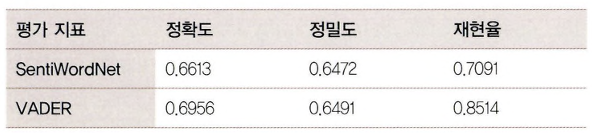

감성 사전을 이용한 감성 분석 예측 성능은 지도학습 분류 기반의 예측 성능에 비해 아직은 낮은 수준이지만 결정 클래스 값이 없는 상황을 고려한다면 예측 성능에 일정 수준 만족할 수 있을 것입니다.